In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 7** - Optimising an ML Model with 6 Hyperparameters (6D)

- Optimising an ML model by tuning six hyperparameters 
    - For example learning rate, regularisation strength or number of hidden layers. 

- The function being maximised is the model's performance score (such as accuracy or F1), treated as a black-box function.

**Input** - 6D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 2.614 at [0.178, 0.332, 0.426, 0.199, 0.304, 0.745] (Week 11)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 7
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy')

# New data from Week 11 (Function 7)
X_w11_new_point = np.array([0.177775, 0.331618, 0.426355, 0.198583, 0.303865, 0.744797], dtype=np.float64)
Y_w11_new_point = np.array([2.6141071649527605], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w11_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w11_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 7: ", X_unique)
print("Updated Outputs (Y) - Function 7: ", Y_updated)

Updated Inputs (X) - Function 7:  [[0.001234   0.887611   0.445322   0.221098   0.990123   0.556712  ]
 [0.004352   0.329864   0.487139   0.079703   0.323502   0.982761  ]
 [0.010322   0.277175   0.892712   0.174897   0.395748   0.738827  ]
 [0.017847   0.815326   0.270978   0.212167   0.499065   0.497593  ]
 [0.022693   0.45861    0.588169   0.516538   0.194504   0.964834  ]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.06661051 0.52804507 0.8160952  0.96101714 0.08650933 0.77778822]
 [0.075291   0.40479    0.382733   0.204853   0.437087   0.746748  ]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.079216   0.382295   0.311153   0.190364   0.301736   0.755824  ]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.096872   0.416732   0.412049   0.161576   0.307971   0.710714  ]
 [0.114899   0.037728   0.781258   0.4947     0.114078   0.883059  ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]


## **Output Analysis**

- This week I got the output of 2.164 which was the all time best and the largest gain in a single week for this function.

    - w11 output went up 25% from 2.083. 
        - The w11 query [0.178, 0.332, 0.426, 0.199, 0.304, 0.745] has x3=0.426, which is within the safe zone but closer to the 0.45 ceiling than previous best results. 

    - x1 increased significantly (0.178 vs 0.097 in w9 best).
        - This suggests x1 may play a more important role than previously assumed.

- **Real-World Implication:** In ML hyperparameter tuning, the jump from 2.083 to 2.614 represents discovering a new operating configuration
    - Perhaps a learning rate and regularisation combination that was previously underweighted in the search. 
    
- The wider std=0.035 in w11 enabled this discovery by sampling a slightly larger neighbourhood than the tight grids of previous weeks.

- **Model Clues:** The W11 best is now the anchor. 

- w12 must exploit this new peak while maintaining the x3 ceiling. 
    - x1≈0.178 appears to be a valuable new finding as the previous searches concentrated x1 near 0.075–0.097.

## **Bayesian Optimisation**

- **Model:** Matern (nu=2.5) + WhiteKernel + Yeo-Johnson. Unchanged — the new best validates the architecture.

- **On Neural Networks:** Function 7 is the most interesting NN candidate in this project as it simulates ML hyperparameter tuning, which is exactly the domain where neural architecture search (NAS) and meta-learning methods are used professionally. 
    - However, with ~35 data points in 6D, a standard feedforward NN would overfit badly.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)
    
model.fit(X_unique, Y_transformed)

Original Y: [0.11990281 0.86440358 1.32634849 0.25791128 0.83814056 1.3649683
 0.51645722 1.71684115 0.00882563 2.08263279 0.00750324 2.1335022
 0.75465759 0.0614243  0.61152553 0.47539552 2.61410716 0.09264495
 0.83359509 0.00701603 0.6044327  0.04211835 0.27489251 0.09541116
 0.0735163  0.01820907 0.56275307 0.2730468  0.0178696  0.10050661
 0.2063097  0.06676325 0.08374657 0.03356494 0.02134252 0.01479818
 0.00313433 0.00270147 0.67514163 0.00377748 0.26840032]
Transformed Y: [-0.51950636  1.1047568   1.43568179  0.00564885  1.07819746  1.45498441
  0.63377382  1.5948983  -1.10638452  1.69288796 -1.11455217  1.70388619
  0.98577023 -0.80568302  0.7928939   0.55542454  1.78608518 -0.64722846
  1.07348536 -1.11756942  0.7819832  -0.91081629  0.05884009 -0.63383403
 -0.74268264 -1.04933299  0.71486151  0.05316084 -1.05136974 -0.6094229
 -0.16988873 -0.77760444 -0.69100851 -0.95927503 -1.03062828 -1.06988965
 -1.14176455 -1.14447998  0.88468328 -1.13773647  0.03875448]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Key change:** Re-centre on the new w11 best [0.178, 0.332, 0.426, 0.199, 0.304, 0.745]. 
    - Maintain x3 ceiling at 0.45. 
        - Use std=0.025 which is tighter than w11's 0.035 since we have a new confirmed peak.

In [4]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w11_best = np.array([0.177775, 0.331618, 0.426355, 0.198583, 0.303865, 0.744797])

x_grid = np.random.normal(loc=w11_best, scale=0.025, size=(8500, 6))

x_uniform = np.random.uniform(0, 1, size=(1500, 6))
x_grid = np.vstack([x_grid, x_uniform])

# Hard ceiling: x3 <= 0.45 — empirically validated
x_grid[:, 2] = np.minimum(x_grid[:, 2], 0.45)
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)

ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w11_best}')
print(f'Strategic Week 12 Query (Function 7): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}')

Best coordinates: [0.177775 0.331618 0.426355 0.198583 0.303865 0.744797]
Strategic Week 12 Query (Function 7): 0.597641-0.013130-0.450000-0.600489-0.099281-0.996713


## **Visualisation**

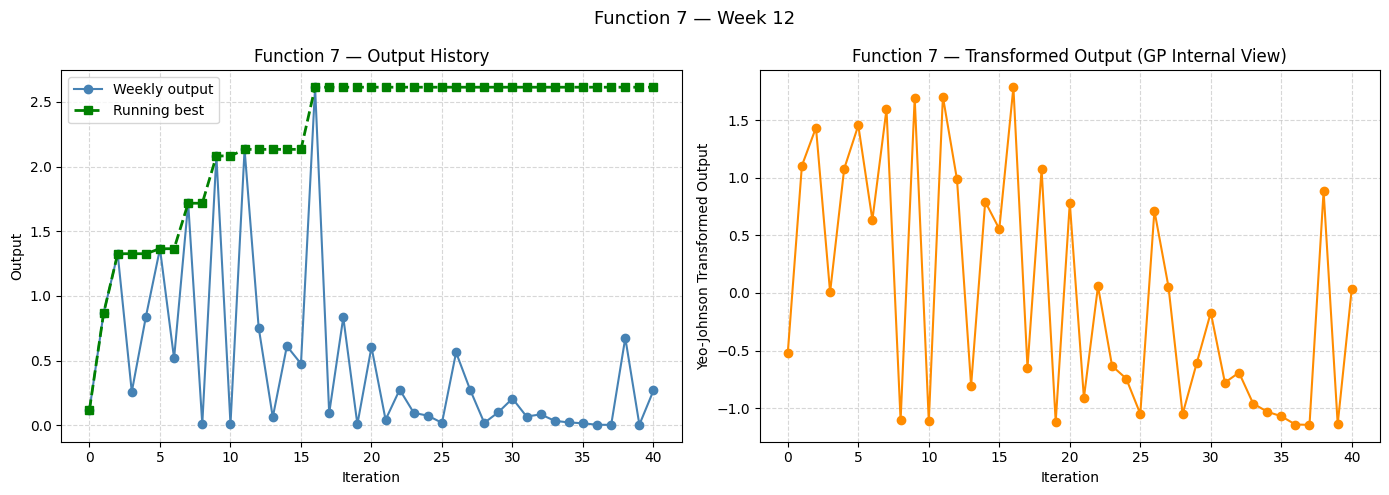

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 7 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 7 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 7 — Week 12', fontsize=13)
plt.tight_layout()
plt.show()